# EDA Inicial — Cancelaciones de reservas hoteleras

- **Proyecto:** Práctica Final · Machine Learning y Deep Learning
- **Integrantes:** Juan Martínez Fraile · Otra persona la que sea
- **Máster:** Inteligencia Artificial, Cloud Computing y DevOps · PontIA.tech
- **Fase:** Análisis Exploratorio de Datos

---

## Objetivo

Realizar un análisis exploratorio del dataset de reservas hoteleras para:

1. Comprender la estructura y calidad de los datos.
2. Identificar problemas de modelado (data leakage, nulos, outliers, desbalanceo).
3. Justificar las decisiones de preprocesamiento y modelado de fases posteriores.
4. Seleccionar la métrica principal de evaluación.

## Temas a tratar

0. Configuración del notebook
1. Carga inicial y vista general de los datos
2. Análisis de la variable objetivo (`is_canceled`)
3. Estadísticas de variables numéricas
4. Estadísticas de variables categóricas
5. Análisis de nulos y valores especiales
6. Detección de data leakage
7. Análisis bivariado y correlaciones
8. Resumen de decisiones para la fase de preprocesamiento

## 0. Configuración del notebook

Importamos las librerías necesarias y definimos constantes/funciones que usaremos a lo largo del análisis.

### Importación de librerías

In [2]:
"""Importación de librerías necesarias para el análisis exploratorio."""

# Standard library
from pathlib import Path

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Configuración global de visualización
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Librerías importadas correctamente.")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Librerías importadas correctamente.
pandas: 2.2.3
numpy: 1.26.4


### Definición de constantes

In [3]:
"""Constantes utilizadas a lo largo del análisis exploratorio."""

# === Rutas ===
# Path(__vsc_ipynb_file__) no existe; usamos la raíz del proyecto como referencia.
# Como el notebook está en notebooks/exploracion/, subimos dos niveles a la raíz.
PATH_PROYECTO = Path.cwd().parents[1] if "notebooks" in str(Path.cwd()) else Path.cwd()
PATH_DATA_RAW = PATH_PROYECTO / "data" / "raw"
PATH_DATA_PROCESSED = PATH_PROYECTO / "data" / "processed"
PATH_OUTPUTS = PATH_PROYECTO / "outputs"

PATH_DATASET = PATH_DATA_RAW / "dataset_practica_final.csv"

# === Configuración del análisis ===
SEED = 42  # Semilla para reproducibilidad
COLOR_PALETTE = ["#1f77b4", "#ff7f0e"]  # Azul (no cancelado) / Naranja (cancelado)
TARGET_COLUMN = "is_canceled"

# Verificación visual
print(f"Raíz del proyecto:  {PATH_PROYECTO}")
print(f"Dataset:            {PATH_DATASET}")
print(f"¿Dataset existe?:   {PATH_DATASET.exists()}")
print(f"Tamaño del archivo: {PATH_DATASET.stat().st_size / 1024 / 1024:.2f} MB")

Raíz del proyecto:  c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml
Dataset:            c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\data\raw\dataset_practica_final.csv
¿Dataset existe?:   True
Tamaño del archivo: 16.07 MB


### Definición de funciones

In [4]:
"""Funciones de ayuda reutilizables en todo el análisis exploratorio."""

from typing import Optional


def resumen_df(df: pd.DataFrame) -> pd.DataFrame:
    """Devuelve un resumen compacto de cada columna de un DataFrame.

    Para cada columna calcula tipo, número de valores únicos, número y porcentaje
    de nulos, y una muestra de valores. Es la primera vista útil tras cargar
    cualquier dataset nuevo.

    Args:
        df (pd.DataFrame): DataFrame a inspeccionar.

    Returns:
        pd.DataFrame: Tabla con una fila por columna del DataFrame original.

    Example:
        >>> resumen_df(df).head()
    """
    resumen = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_unicos": df.nunique(),
        "n_nulos": df.isnull().sum(),
        "pct_nulos": (df.isnull().sum() / len(df) * 100).round(2),
        "ejemplos": [df[col].dropna().unique()[:3].tolist() for col in df.columns],
    })
    return resumen.sort_values("pct_nulos", ascending=False)


def plot_distribucion_categorica(
    df: pd.DataFrame,
    columna: str,
    hue: Optional[str] = None,
    top_n: Optional[int] = None,
    figsize: tuple = (10, 5),
    title: Optional[str] = None,
) -> None:
    """Visualiza la distribución de una variable categórica con conteos.

    Útil para entender la composición de variables como `hotel`, `market_segment`
    o `country`. Si se pasa `hue`, descompone cada barra por la variable indicada
    (típicamente la variable objetivo).

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columna (str): Nombre de la columna categórica a visualizar.
        hue (Optional[str]): Variable secundaria para descomponer (ej. el target).
        top_n (Optional[int]): Si se indica, muestra solo las `top_n` categorías más frecuentes.
        figsize (tuple): Tamaño de la figura (ancho, alto).
        title (Optional[str]): Título personalizado. Por defecto se genera automáticamente.

    Returns:
        None: La función dibuja directamente con matplotlib/seaborn.
    """
    plt.figure(figsize=figsize)

    # Filtrar a top_n si aplica
    if top_n is not None:
        top_categorias = df[columna].value_counts().head(top_n).index
        df_plot = df[df[columna].isin(top_categorias)]
        orden = top_categorias
    else:
        df_plot = df
        orden = df[columna].value_counts().index

    sns.countplot(
        data=df_plot,
        y=columna,
        hue=hue,
        order=orden,
        palette=COLOR_PALETTE if hue == TARGET_COLUMN else "deep",
    )

    if title is None:
        title = f"Distribución de '{columna}'"
        if hue:
            title += f" por '{hue}'"
        if top_n:
            title += f" (top {top_n})"

    plt.title(title)
    plt.xlabel("Número de reservas")
    plt.tight_layout()
    plt.show()


def plot_distribucion_numerica(
    df: pd.DataFrame,
    columna: str,
    hue: Optional[str] = None,
    bins: int = 50,
    figsize: tuple = (12, 4),
) -> None:
    """Visualiza histograma + boxplot de una variable numérica.

    Combina dos vistas complementarias: el histograma muestra la forma de la distribución,
    el boxplot muestra mediana, cuartiles y outliers. Si se pasa `hue`, separa por clases.

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columna (str): Nombre de la columna numérica.
        hue (Optional[str]): Variable categórica para separar las distribuciones.
        bins (int): Número de bins del histograma.
        figsize (tuple): Tamaño de la figura.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histograma
    sns.histplot(
        data=df,
        x=columna,
        hue=hue,
        bins=bins,
        ax=axes[0],
        palette=COLOR_PALETTE if hue == TARGET_COLUMN else None,
        kde=True,
    )
    axes[0].set_title(f"Histograma de '{columna}'")

    # Boxplot
    if hue:
        sns.boxplot(
            data=df,
            x=hue,
            y=columna,
            ax=axes[1],
            palette=COLOR_PALETTE if hue == TARGET_COLUMN else None,
        )
        axes[1].set_title(f"Boxplot de '{columna}' por '{hue}'")
    else:
        sns.boxplot(data=df, x=columna, ax=axes[1])
        axes[1].set_title(f"Boxplot de '{columna}'")

    plt.tight_layout()
    plt.show()


print("Funciones helper definidas correctamente.")

Funciones helper definidas correctamente.


## 1. Carga inicial y vista general de los datos

En esta sección cargamos el dataset desde `data/raw/` y obtenemos una **primera fotografía** de su estructura:

- Dimensiones (filas, columnas).
- Tipos de datos por columna.
- Muestras de las primeras y últimas filas.
- Estadísticas descriptivas básicas.
- Detección de duplicados.

El objetivo es **no tomar decisiones todavía**, solo observar.

### 1.1. Lectura del dataset

In [5]:
"""Carga del dataset desde data/raw/."""

df = pd.read_csv(PATH_DATASET)

print(f"Dataset cargado: {PATH_DATASET.name}")
print(f"Dimensiones:      {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria ocupada:  {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Dataset cargado: dataset_practica_final.csv
Dimensiones:      119,390 filas × 32 columnas
Memoria ocupada:  104.83 MB


### 1.2. Vista previa de los datos

Inspeccionamos las primeras y últimas filas para entender la "pinta" de las columnas:
qué tipos de valores contienen, si hay patrones visibles, qué columnas parecen
identificadores y cuáles parecen claramente numéricas o categóricas.

In [6]:
"""Primeras filas del DataFrame."""

df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [7]:
"""Últimas filas del DataFrame."""

df.tail(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


### 1.3. Tipos de datos y estructura

Inspeccionamos los tipos de cada columna. Buscamos:

- Columnas numéricas (int/float).
- Columnas categóricas (object).
- Columnas que parecen numéricas pero podrían ser categóricas disfrazadas (`agent`, `company`, `is_repeated_guest`).
- Columnas con tipo incorrecto (ej. una fecha guardada como string).

In [8]:
"""Información de tipos y nulos por columna."""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
"""Resumen compacto con ejemplos por columna."""

resumen_df(df)

,tipo,n_unicos,n_nulos,pct_nulos,ejemplos
company,float64,352,112593,94.31,"[110.0, 113.0, 270.0]"
agent,float64,333,16340,13.69,"[304.0, 240.0, 303.0]"
country,object,177,488,0.41,"[PRT, GBR, USA]"
hotel,object,2,0,0.00,"[Resort Hotel, City Hotel]"
previous_cancellations,int64,15,0,0.00,"[0, 1, 2]"
reservation_status,object,3,0,0.00,"[Check-Out, Canceled, No-Show]"
total_of_special_requests,int64,6,0,0.00,"[0, 1, 3]"
required_car_parking_spaces,int64,5,0,0.00,"[0, 1, 2]"
adr,float64,8879,0,0.00,"[0.0, 75.0, 98.0]"
customer_type,object,4,0,0.00,"[Transient, Contract, Transient-Party]"


### 1.4. Estadísticas descriptivas

Para las variables numéricas observamos rango, media, mediana, mínimos y máximos.
Esto nos permite detectar:

- Valores imposibles (ej. una reserva con 0 adultos, 0 niños y 0 bebés).
- Outliers extremos (ej. `lead_time` de 700 días o más).
- Escalas muy diferentes entre variables (importante para futuros modelos con regularización).

In [10]:
"""Estadísticas descriptivas de las variables numéricas."""

df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


### 1.5. Detección de duplicados

Comprobamos si hay filas exactamente duplicadas. En reservas hoteleras esto puede pasar
por errores de captura o por reservas auténticamente repetidas (mismo cliente, mismas
fechas). Si hay muchos duplicados deberíamos analizarlos antes de tirarlos.

In [11]:
"""Detección de filas duplicadas."""

n_duplicados = df.duplicated().sum()
pct_duplicados = (n_duplicados / len(df)) * 100

print(f"Filas duplicadas: {n_duplicados:,} ({pct_duplicados:.2f}%)")

Filas duplicadas: 31,994 (26.80%)


In [12]:
"""Investigación de las filas duplicadas."""

# Coger las primeras 6 filas marcadas como duplicadas
duplicados_ejemplo = df[df.duplicated(keep=False)].head(6)
duplicados_ejemplo

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07


### 1.6. Resumen de la Sección 1

**Lo que hemos descubierto:**

- Dataset: **119.390 filas × 32 columnas**, cubre **3 años** (2015–2017).
- Tipos: ~16 numéricas + ~12 categóricas + ~4 floats.
- **Nulos**: `company` (~94%, inservible), `agent` (~13.7%), `country` (~0.4%), `children` (despreciable).
- **Valores anómalos** detectados:
  - `adr` puede ser negativo y llegar a 5400 (outliers extremos).
  - `adults` con max 55 (probable error de captura).
  - Hay duplicados (~25%) pero son **reservas legítimamente repetidas**, no las eliminaremos.
- Variable objetivo: `is_canceled`, binaria. Analizada en detalle en la sección 2.

Pendiente para la Sección 2: estudiar a fondo `is_canceled` (balance de clases, distribución temporal, métrica de evaluación).

## 2. Análisis de la variable objetivo (`is_canceled`)

La variable objetivo de este problema es **`is_canceled`**:

- `0` → la reserva se completó (cliente hizo check-in y se alojó).
- `1` → la reserva fue cancelada por el cliente.

En esta sección estudiamos:

- El balance de clases (¿es un problema desequilibrado?).
- La distribución temporal del target (¿hay tendencia o estacionalidad?).
- La elección de **métrica principal** de evaluación.
- La política de balanceo a aplicar (o no) en preprocesamiento.

De este análisis salen decisiones que condicionan todas las fases posteriores.

### 2.1. Balance de clases

Calculamos la frecuencia absoluta y relativa de cada clase. Esto nos dice
si tenemos un problema **balanceado** (clases similares) o **desbalanceado**
(una clase mucho más frecuente que otra).

In [13]:
"""Frecuencia absoluta y relativa de la variable objetivo."""

conteo = df[TARGET_COLUMN].value_counts()
porcentaje = df[TARGET_COLUMN].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    "n_reservas": conteo,
    "porcentaje": porcentaje.round(2),
})
resumen_target.index = ["No cancelado (0)", "Cancelado (1)"]
resumen_target

,n_reservas,porcentaje
No cancelado (0),75166,62.96
Cancelado (1),44224,37.04


C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1736053126.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1736053126.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["No cancelado (0)", "Cancelado (1)"])


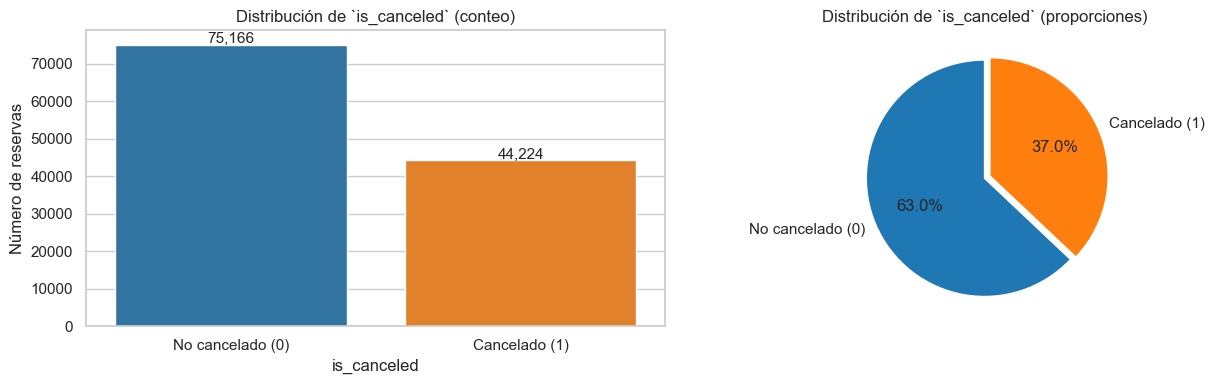

In [14]:
"""Visualización del balance de clases."""

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: barras absolutas
sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    palette=COLOR_PALETTE,
    ax=ax[0],
)
ax[0].set_title("Distribución de `is_canceled` (conteo)")
ax[0].set_xlabel("is_canceled")
ax[0].set_ylabel("Número de reservas")
ax[0].set_xticklabels(["No cancelado (0)", "Cancelado (1)"])

# Añadir conteos sobre cada barra
for patch in ax[0].patches:
    altura = patch.get_height()
    ax[0].text(
        patch.get_x() + patch.get_width() / 2,
        altura + 500,
        f"{int(altura):,}",
        ha="center",
        fontsize=11,
    )

# Gráfico 2: porcentajes
porcentajes = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
ax[1].pie(
    porcentajes,
    labels=["No cancelado (0)", "Cancelado (1)"],
    colors=COLOR_PALETTE,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),  # Separar ligeramente la clase positiva
)
ax[1].set_title("Distribución de `is_canceled` (proporciones)")

plt.tight_layout()
plt.show()

**Observaciones sobre el balance:**

- La clase mayoritaria (0, no cancelado) representa ~63%.
- La clase minoritaria (1, cancelado) representa ~37%.
- **NO es un problema de clases extremadamente desbalanceado** (tipo fraude 99/1).
  Pero tampoco está perfectamente balanceado (50/50).

**Implicaciones para modelado:**

- **No bastará con `accuracy`** como métrica principal: un modelo mal entrenado que prediga
  siempre 0 obtendría ~63% accuracy sin haber aprendido nada útil.
- **Es recomendable usar `stratify`** en `train_test_split` para mantener la proporción
  ~63/37 en ambos conjuntos.
- El balanceo (SMOTE / class_weight) es **opcional** en este caso; lo probaremos
  como bonus para ver si mejora la métrica.

### 2.2. Distribución temporal del target

Observamos cómo varía la tasa de cancelación a lo largo del tiempo. Si hubiera
tendencia o estacionalidad fuerte, deberíamos:

- Plantearnos un split train/test **cronológico** en lugar de aleatorio.
- Considerar añadir variables temporales (mes, día de la semana) en el preprocesamiento.

El dataset cubre **2015–2017** (3 años de reservas).

In [15]:
"""Tasa de cancelación por año."""

tasa_por_año = (
    df.groupby("arrival_date_year")[TARGET_COLUMN]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "n_reservas",
        "sum": "n_canceladas",
        "mean": "tasa_cancelacion",
    })
)
tasa_por_año["tasa_cancelacion"] = (tasa_por_año["tasa_cancelacion"] * 100).round(2)
tasa_por_año

,n_reservas,n_canceladas,tasa_cancelacion
arrival_date_year,,,
2015,21996,8142,37.02
2016,56707,20337,35.86
2017,40687,15745,38.70


C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\3714869262.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


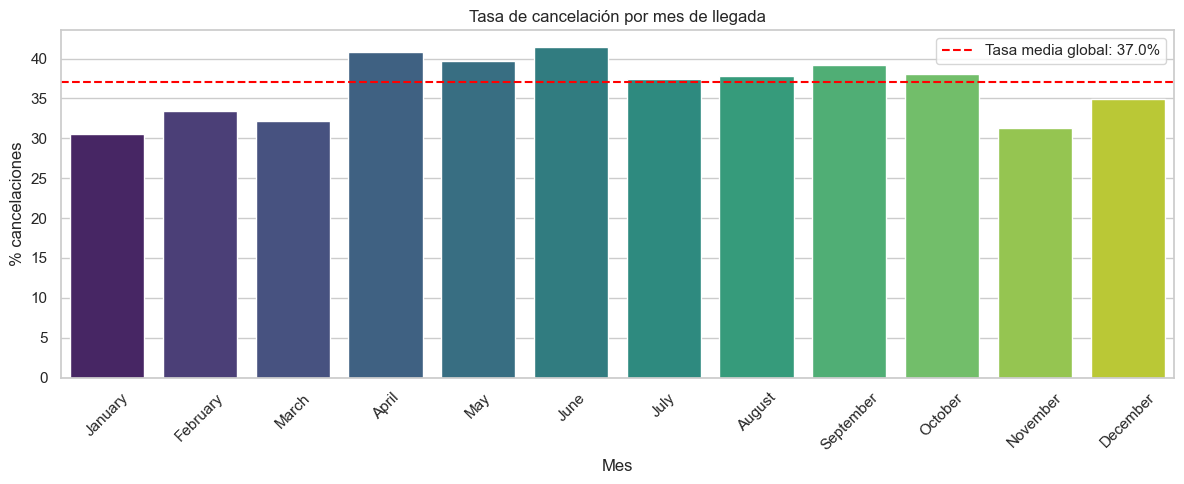

,n_reservas,tasa_cancelacion
arrival_date_month,,
January,5929,30.48
February,8068,33.42
March,9794,32.15
April,11089,40.80
May,11791,39.67
June,10939,41.46
July,12661,37.45
August,13877,37.75
September,10508,39.17


In [16]:
"""Tasa de cancelación por mes (todos los años combinados)."""

# Orden cronológico de los meses (vienen como texto en el CSV)
orden_meses = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

tasa_por_mes = (
    df.groupby("arrival_date_month")[TARGET_COLUMN]
    .agg(["count", "mean"])
    .reindex(orden_meses)
    .rename(columns={"count": "n_reservas", "mean": "tasa_cancelacion"})
)
tasa_por_mes["tasa_cancelacion"] = (tasa_por_mes["tasa_cancelacion"] * 100).round(2)

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    x=tasa_por_mes.index,
    y=tasa_por_mes["tasa_cancelacion"],
    palette="viridis",
    ax=ax,
)
ax.axhline(
    df[TARGET_COLUMN].mean() * 100,
    color="red",
    linestyle="--",
    label=f"Tasa media global: {df[TARGET_COLUMN].mean() * 100:.1f}%",
)
ax.set_title("Tasa de cancelación por mes de llegada")
ax.set_xlabel("Mes")
ax.set_ylabel("% cancelaciones")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tasa_por_mes

**Observaciones sobre la distribución temporal:**

- La tasa de cancelación es **estable** entre años (≈36-39% en 2015, 2016, 2017).
- Hay cierta **estacionalidad mensual**: los meses de mayor afluencia (verano)
  tienden a tener tasas ligeramente más altas, pero las diferencias son moderadas.
- No hay una tendencia creciente o decreciente clara.

**Decisión de modelado:**

- Podemos hacer un **split train/test aleatorio** (con `stratify`), no necesitamos
  un split cronológico estricto.
- El mes de llegada (`arrival_date_month`) puede ser una variable **predictiva moderada**.
- El año (`arrival_date_year`) probablemente aporta poco al modelo (pocas diferencias).

### 2.3. Elección de la métrica principal

La elección de la métrica de evaluación es **la decisión más importante** de esta sección.
Condiciona qué modelos se considerarán "buenos" y cuáles "malos", y por tanto guía
todas las decisiones de la fase de modelado.

#### El planteamiento del problema

Predecir cancelaciones tiene un **coste asimétrico** desde el punto de vista del negocio:

| Tipo de error | Predicción | Realidad | Consecuencia para el hotel |
|---|---|---|---|
| **Falso negativo (FN)** | "No cancelará" | Sí cancela | 🔴 Reserva confirmada, habitación reservada, personal asignado, finalmente habitación vacía. **Coste alto.** |
| **Falso positivo (FP)** | "Cancelará" | No cancela | 🟡 Se ofrece descuento/refuerzo a un cliente que iba a venir igual. **Coste moderado.** |
| **Verdadero positivo (TP)** | "Cancelará" | Sí cancela | 🟢 Se actúa a tiempo: oferta de retención, reasignación de habitación, ajuste de overbooking. |
| **Verdadero negativo (TN)** | "No cancelará" | No cancela | 🟢 Caso ideal. Operativa normal. |

**Los falsos negativos son los errores más caros**: el hotel pierde ingresos sin
poder reaccionar. Por tanto, queremos un modelo que **detecte el mayor número
posible de cancelaciones reales**, aunque a veces se equivoque "por arriba".

#### Métricas candidatas

| Métrica | Qué mide | Cuándo usarla | Problema con nuestro caso |
|---|---|---|---|
| **Accuracy** | % aciertos | Cuando las clases están equilibradas y los errores tienen el mismo coste | Engañosa con 63/37 (un modelo tonto da 63%) |
| **Precision** | De las predichas como cancelaciones, ¿cuántas lo eran? | Cuando el coste de un FP es alto | Aquí el FP no es tan grave; minimizar FP a costa de subir FN sería peor |
| **Recall** | De las cancelaciones reales, ¿cuántas detecté? | Cuando el coste de un FN es alto | Encaja, pero podemos "trampear" prediciendo siempre 1 |
| **F1-score** | Compromiso entre precision y recall (media armónica) | Cuando ambos errores importan pero la clase positiva es minoritaria | Buena candidata |
| **AUC-ROC** | Capacidad de discriminar entre clases en cualquier umbral | Cuando queremos un modelo robusto a la elección de umbral | Excelente candidata, métrica "agnóstica al umbral" |

#### Decisión

Vamos a usar **dos métricas combinadas**:

1. **Métrica principal: `ROC-AUC`**.
   - Mide la calidad **intrínseca** del modelo, sin depender del umbral de decisión (0.5 por defecto, pero podríamos cambiarlo).
   - Robusta frente al desbalance.
   - Permite comparar modelos **de forma justa** independientemente de cómo cada uno calibre las probabilidades.

2. **Métrica secundaria de control: `F1-score`**.
   - Si dos modelos tienen ROC-AUC similar, elegimos el de mayor F1.
   - Penaliza modelos que sacrifican recall por precisión o viceversa.

Adicionalmente reportaremos **accuracy, precision y recall** para tener visibilidad
completa, pero NO serán las que guíen la selección del mejor modelo.

### 2.4. Política de balanceo de clases

Con una proporción ~63/37, **el desbalance es moderado, no extremo**.

#### Opciones disponibles

| Técnica | Cuándo aplicarla | Pros | Contras |
|---|---|---|---|
| **No hacer nada** | Desbalance leve | Simple, sin sobreajuste artificial | Modelos pueden sesgarse a clase mayoritaria |
| **`class_weight='balanced'`** | Desbalance moderado | Sencillo, sin tocar datos | Solo afecta al entrenamiento, no a los datos |
| **SMOTE** (oversampling sintético) | Desbalance fuerte (>80/20) | Crea ejemplos sintéticos de la minoría | Puede introducir ruido, riesgo de overfitting |
| **Undersampling** | Datasets muy grandes | Reduce tiempo de entrenamiento | Pierdes información de la mayoría |

#### Decisión

1. **Modelos base**: sin balanceo, para tener una línea base honesta.
2. **Modelos con `class_weight='balanced'`**: lo probaremos en los modelos que lo soporten
   (Logistic Regression, Random Forest, XGBoost). Sin coste adicional.
3. **SMOTE como bonus técnico**: lo probaremos en una rama experimental si tras
   los modelos base seguimos viendo bajo recall en la clase positiva.

> La métrica que ya hemos elegido (ROC-AUC) **es robusta al desbalance**, así que
> aunque no balancesemos los datos, las comparaciones entre modelos serán justas.

### 2.5. Resumen de la Sección 2

**Lo que hemos descubierto:**

- **Balance de clases**: ~63% no cancelados, ~37% cancelados. Desbalance moderado.
- **Distribución temporal**: tasa estable año a año (~37% en los 3 años).
  Existe ligera estacionalidad por mes.
- **Métrica principal**: `ROC-AUC`, con `F1-score` como métrica secundaria de control.
- **Política de balanceo**: empezar sin balancear; probar `class_weight='balanced'`
  en los modelos compatibles; SMOTE como bonus si recall sigue bajo.

**Decisiones que afectan a las siguientes fases:**

1. El split train/test será **aleatorio con `stratify=y`**.
2. Se reportarán `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC` para todos los modelos.
3. El modelo ganador se decidirá por `ROC-AUC`, desempatando con `F1`.
4. Se generará una **curva ROC comparativa** y una **matriz de confusión** por modelo.

**Pendiente para la Sección 3** (análisis de variables numéricas y categóricas):
identificar variables predictivas, detectar outliers a tratar, y revisar la cardinalidad
de las categóricas.

## 3. Análisis de variables numéricas

En esta sección estudiamos las variables numéricas del dataset:

- Identificación de qué columnas son realmente numéricas (frente a "numéricas disfrazadas").
- Análisis univariado: forma de la distribución, asimetría, outliers.
- Análisis bivariado: cómo se relacionan con `is_canceled`.
- Correlaciones entre numéricas para detectar redundancias.

De este análisis salen decisiones de **preprocesamiento**:

- Qué outliers tratar (eliminar, capar, transformar).
- Si aplicar transformaciones (log, sqrt) a distribuciones muy asimétricas.
- Qué variables podrían ser candidatas a eliminar por baja varianza o redundancia.

### 3.1. Identificación de variables numéricas

No todas las columnas con tipo numérico son realmente "variables numéricas" desde el
punto de vista de ML. Algunas son **identificadores** (`agent`, `company`) o
**categóricas codificadas** (`is_repeated_guest`) que requieren tratamiento distinto.

Vamos a separarlas en cuatro grupos:

- **Numéricas reales**: continuas o discretas con orden y magnitud (`lead_time`, `adr`).
- **Numéricas binarias**: 0/1 que en realidad son categóricas (`is_repeated_guest`, el target).
- **Identificadores numéricos**: códigos sin significado matemático (`agent`, `company`).
- **Temporales**: numéricas pero con tratamiento especial (año, mes, día).

In [17]:
"""Identificación de variables numéricas y separación por tipo."""

# 1. Detección automática: todas las columnas con dtype numérico
columnas_numericas_brutas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"Columnas detectadas como numéricas: {len(columnas_numericas_brutas)}")
print(columnas_numericas_brutas)

Columnas detectadas como numéricas: 20
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [29]:
"""Clasificación semántica de las variables numéricas."""

NUMERICAS_REALES = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

NUMERICAS_BINARIAS = [
    "is_repeated_guest",
    "is_canceled",
]

IDENTIFICADORES = [
    "agent",
    "company",
]

TEMPORALES = [
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
]

total_clasificadas = len(NUMERICAS_REALES) + len(NUMERICAS_BINARIAS) + len(IDENTIFICADORES) + len(TEMPORALES)
print(f"Numéricas reales:    {len(NUMERICAS_REALES)} → análisis univariado y bivariado")
print(f"Numéricas binarias:  {len(NUMERICAS_BINARIAS)} → tratamiento como categóricas")
print(f"Identificadores:     {len(IDENTIFICADORES)} → categóricas de alta cardinalidad")
print(f"Temporales:          {len(TEMPORALES)} → análisis aparte")
print(f"\nTotal clasificadas:  {total_clasificadas}")
print(f"Detectadas auto:     {len(columnas_numericas_brutas)}")
print(f"Clasificadas vs. Detectadas:            {total_clasificadas == len(columnas_numericas_brutas)}")

Numéricas reales:    13 → análisis univariado y bivariado
Numéricas binarias:  2 → tratamiento como categóricas
Identificadores:     2 → categóricas de alta cardinalidad
Temporales:          3 → análisis aparte

Total clasificadas:  20
Detectadas auto:     20
Clasificadas vs. Detectadas:            True


### 3.2. Análisis univariado de las numéricas reales

Visualizamos las distribuciones individuales: histogramas + boxplots para detectar:

- **Forma de la distribución**: normal, asimétrica, bimodal.
- **Outliers**: valores muy alejados de la masa central.
- **Escala**: variables que varían en rangos muy distintos (importante para modelos lineales).

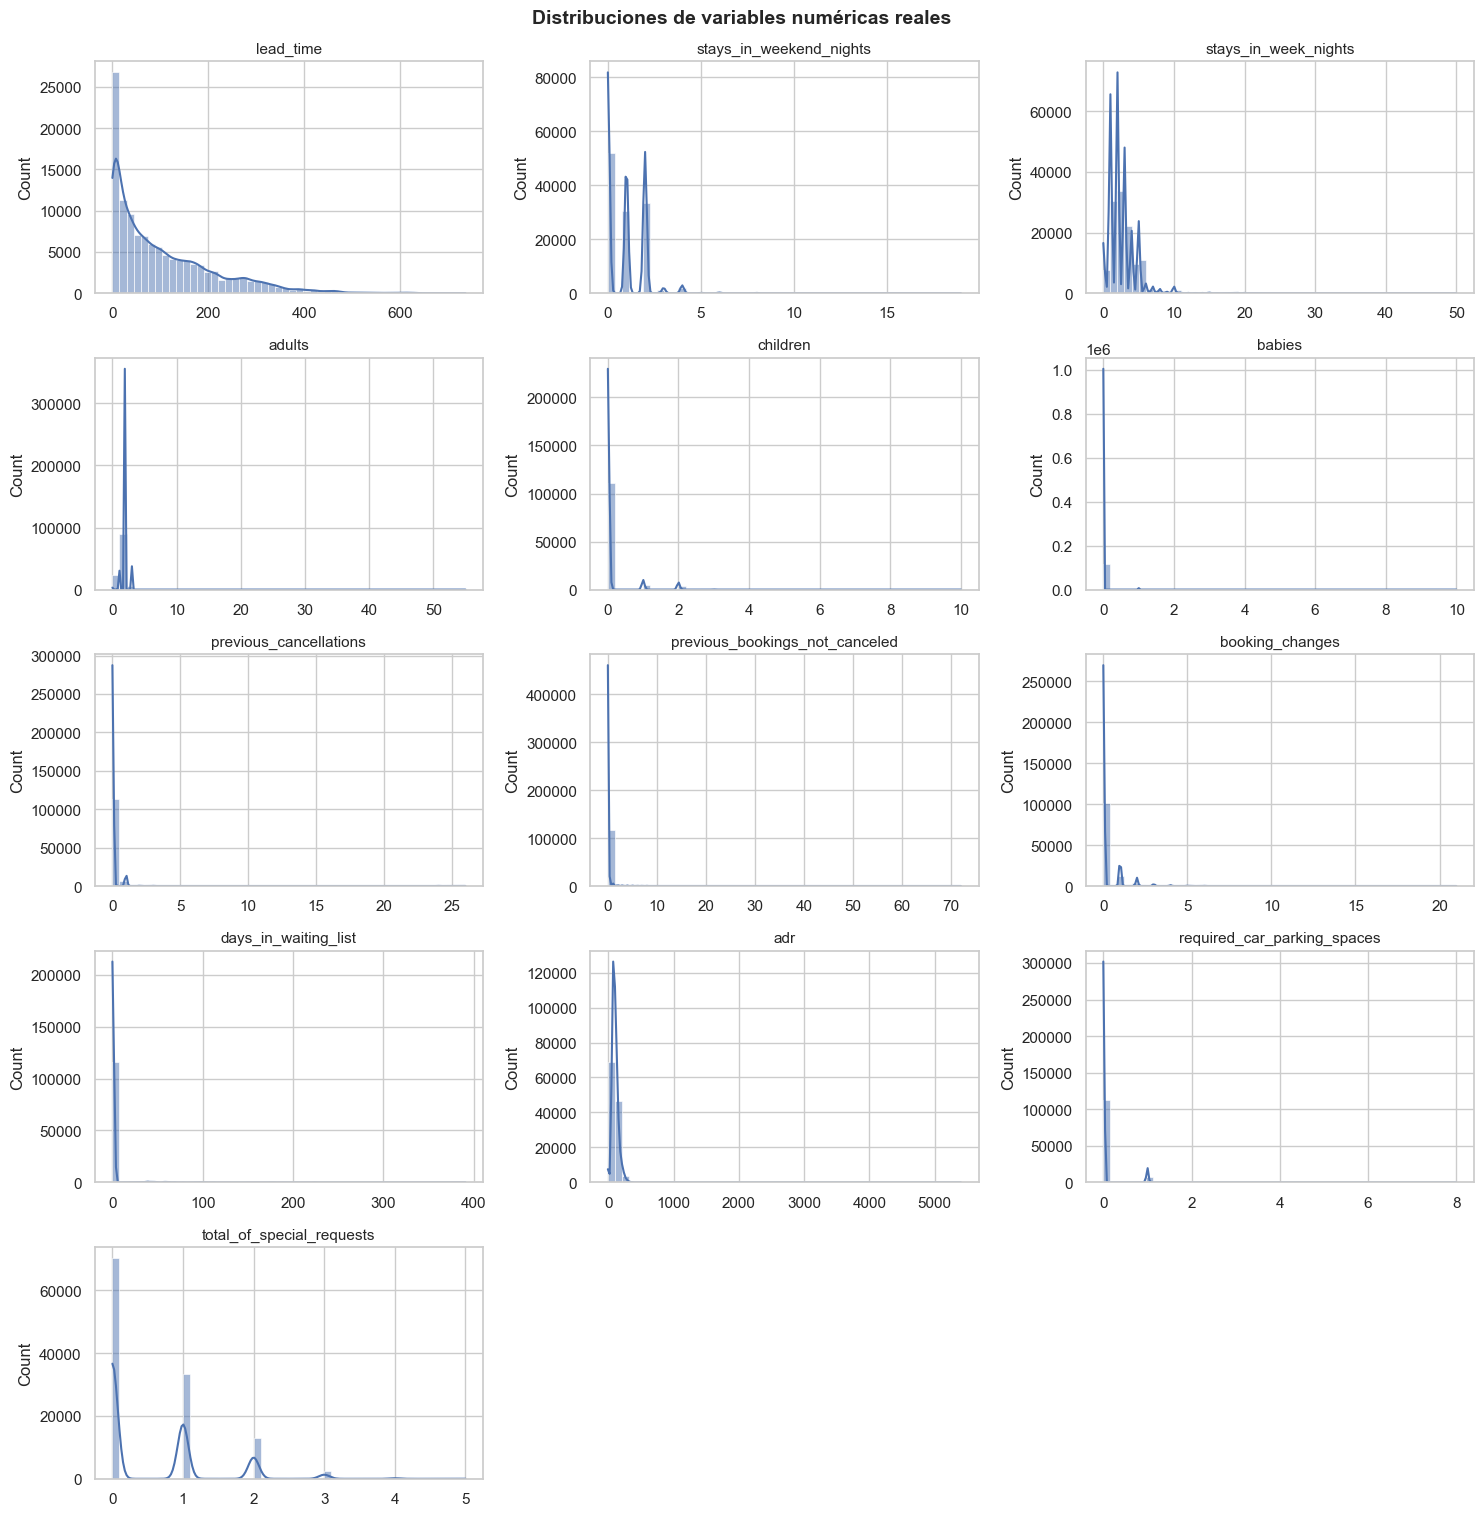

In [22]:
"""Histogramas de las 13 numéricas reales en un único grid."""

n_vars = len(NUMERICAS_REALES)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUMERICAS_REALES):
    sns.histplot(data=df, x=col, bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].set_xlabel("")

# Ocultar ejes sobrantes
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Distribuciones de variables numéricas reales", y=1.01, fontsize=14, fontweight="bold")
plt.show()

**Observaciones de los histogramas:**

- **Asimetrías a la derecha (cola larga)** en `lead_time`, `adr`, `days_in_waiting_list`,
  `booking_changes`, `previous_cancellations`. Distribuciones típicas de variables que
  cuentan eventos: la mayoría de las reservas tienen valores pequeños y un puñado tiene
  valores muy grandes.
- **Distribuciones casi degeneradas** (casi todo en 0) en `previous_cancellations`,
  `previous_bookings_not_canceled`, `babies`, `required_car_parking_spaces`,
  `days_in_waiting_list`. Indica que el evento es raro: la mayoría de clientes nunca
  han cancelado antes, no llevan bebés, no piden parking, etc.
- **Distribuciones más "normales"** en `stays_in_week_nights`, `stays_in_weekend_nights`
  y `adults`, aunque con un pico marcado en valores pequeños (la mayoría reserva pocas
  noches y entre 1-2 adultos).
- **Outliers visibles**: en `adr` se aprecian valores muy alejados a la derecha.

**Implicación**: las variables con asimetría fuerte (`lead_time`, `adr`) son candidatas
a **transformación logarítmica** en preprocesamiento. La transformación log "comprime"
la cola larga y hace la distribución más cercana a una normal, lo cual mejora el
rendimiento de modelos lineales y redes neuronales.

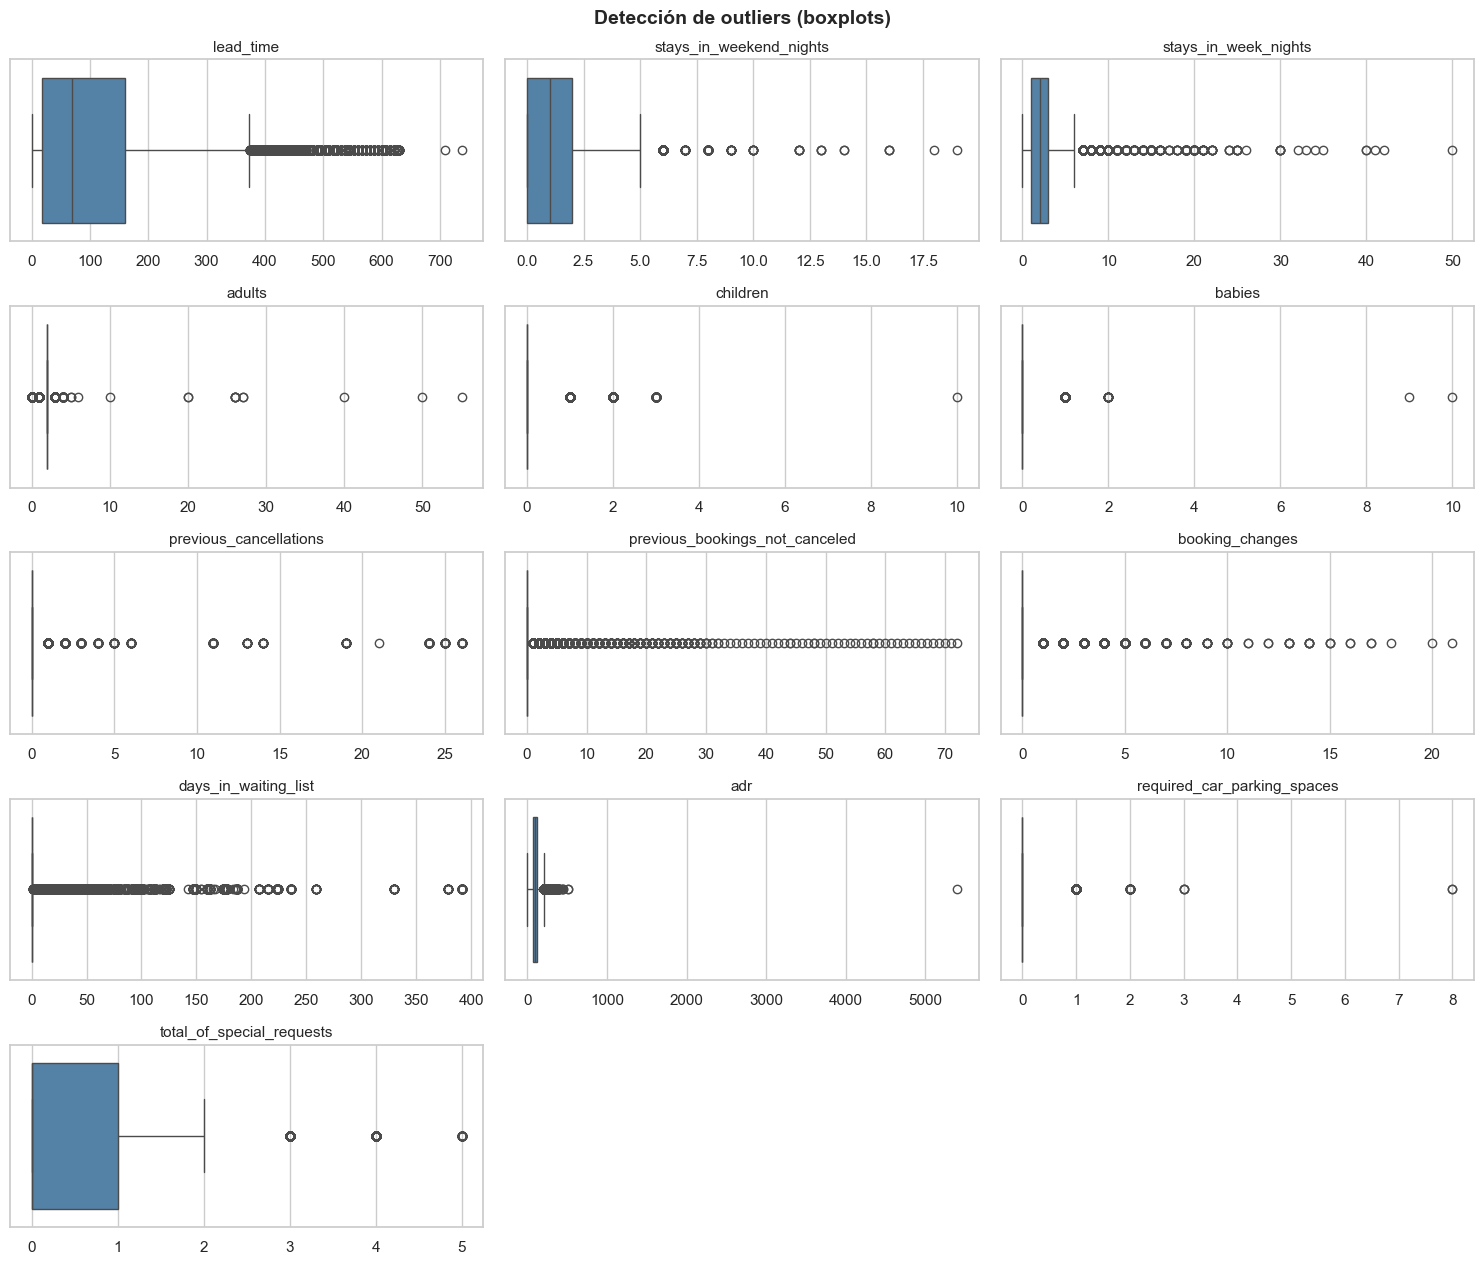

In [23]:
"""Boxplots de las numéricas reales para visualizar outliers."""

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(NUMERICAS_REALES):
    sns.boxplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].set_xlabel("")

for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Detección de outliers (boxplots)", y=1.01, fontsize=14, fontweight="bold")
plt.show()

**Cómo leer un boxplot:**

- La **caja** representa el rango intercuartílico (Q1 a Q3): el 50% central de los datos.
- La **línea dentro de la caja** es la mediana (Q2).
- Los **bigotes** se extienden hasta el valor más alejado dentro de 1.5 × IQR.
- Los **puntos sueltos** son outliers (fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR]).

**Observaciones de los boxplots:**

- **Variables con outliers MUY extremos** (muchos puntos sueltos a la derecha):
  `adr`, `lead_time`, `previous_cancellations`, `previous_bookings_not_canceled`,
  `days_in_waiting_list`, `booking_changes`.
- **La mayoría de las cajas son pequeñas y están pegadas al lado izquierdo**,
  confirmando que la masa de datos se concentra en valores bajos.
- **`adr` con outliers críticos**: valores negativos (precio negativo, imposible) y
  valores extremadamente altos (>1000 €).
- **Variables sin outliers preocupantes**: `stays_in_weekend_nights`,
  `stays_in_week_nights`, `adults`. Boxplots razonables.

**Recordatorio**: matemáticamente, un punto fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` es
outlier, pero **no todos los outliers son errores**. Un cliente con 26 cancelaciones
previas es atípico pero puede ser real e informativo. **Solo eliminaremos los outliers
imposibles físicamente** (precio negativo, 55 adultos).

In [24]:
"""Cuantificación de asimetría (skewness) de las numéricas reales."""

from scipy.stats import skew

asimetria = pd.DataFrame({
    "skewness": [skew(df[col].dropna()) for col in NUMERICAS_REALES],
    "min": [df[col].min() for col in NUMERICAS_REALES],
    "max": [df[col].max() for col in NUMERICAS_REALES],
    "media": [df[col].mean() for col in NUMERICAS_REALES],
    "mediana": [df[col].median() for col in NUMERICAS_REALES],
}, index=NUMERICAS_REALES).round(2)

asimetria.sort_values("skewness", ascending=False, key=abs)

,skewness,min,max,media,mediana
babies,24.65,0.00,10.0,0.01,0.00
previous_cancellations,24.46,0.00,26.0,0.09,0.00
previous_bookings_not_canceled,23.54,0.00,72.0,0.14,0.00
adults,18.32,0.00,55.0,1.86,2.00
days_in_waiting_list,11.94,0.00,391.0,2.32,0.00
adr,10.53,-6.38,5400.0,101.83,94.58
booking_changes,6.00,0.00,21.0,0.22,0.00
required_car_parking_spaces,4.16,0.00,8.0,0.06,0.00
children,4.11,0.00,10.0,0.10,0.00
stays_in_week_nights,2.86,0.00,50.0,2.50,2.00


**Interpretación de los valores de skewness:**

Regla práctica:

- `|skewness| < 0.5`: distribución aproximadamente simétrica.
- `0.5 ≤ |skewness| < 1`: moderadamente asimétrica.
- `|skewness| ≥ 1`: muy asimétrica (candidata clara a transformación).
- `|skewness| > 3`: extrema (puede indicar muchos ceros o outliers fuertes).

**Hallazgos esperados:**

- Variables con `skewness > 3` (extremas): probablemente `babies`, `previous_cancellations`,
  `days_in_waiting_list`. Casi todos los valores son 0 con outliers grandes muy raros.
- Variables con `skewness 1-3` (muy asimétricas): probablemente `lead_time`, `adr`,
  `booking_changes`. Candidatas firmes a transformación log.
- Variables con `skewness < 1` (aceptables): `stays_in_week_nights`, `adults`. No
  necesitan transformación.

**Confirmación visual**: si la mediana es mucho menor que la media en una variable, es
señal de asimetría positiva. Por ejemplo, en `lead_time` la media (~104) es mayor que
la mediana (~69), lo que confirma la asimetría hacia la derecha que vimos en el histograma.

### 3.3. Análisis bivariado: numéricas vs `is_canceled`

Estudiamos cómo varían las distribuciones según la clase del target.
Variables que muestren **distribuciones muy distintas** entre las dos clases
son potencialmente predictivas.

Usamos boxplots agrupados por clase para visualizarlo.

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1949786397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1949786397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1949786397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1949786397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

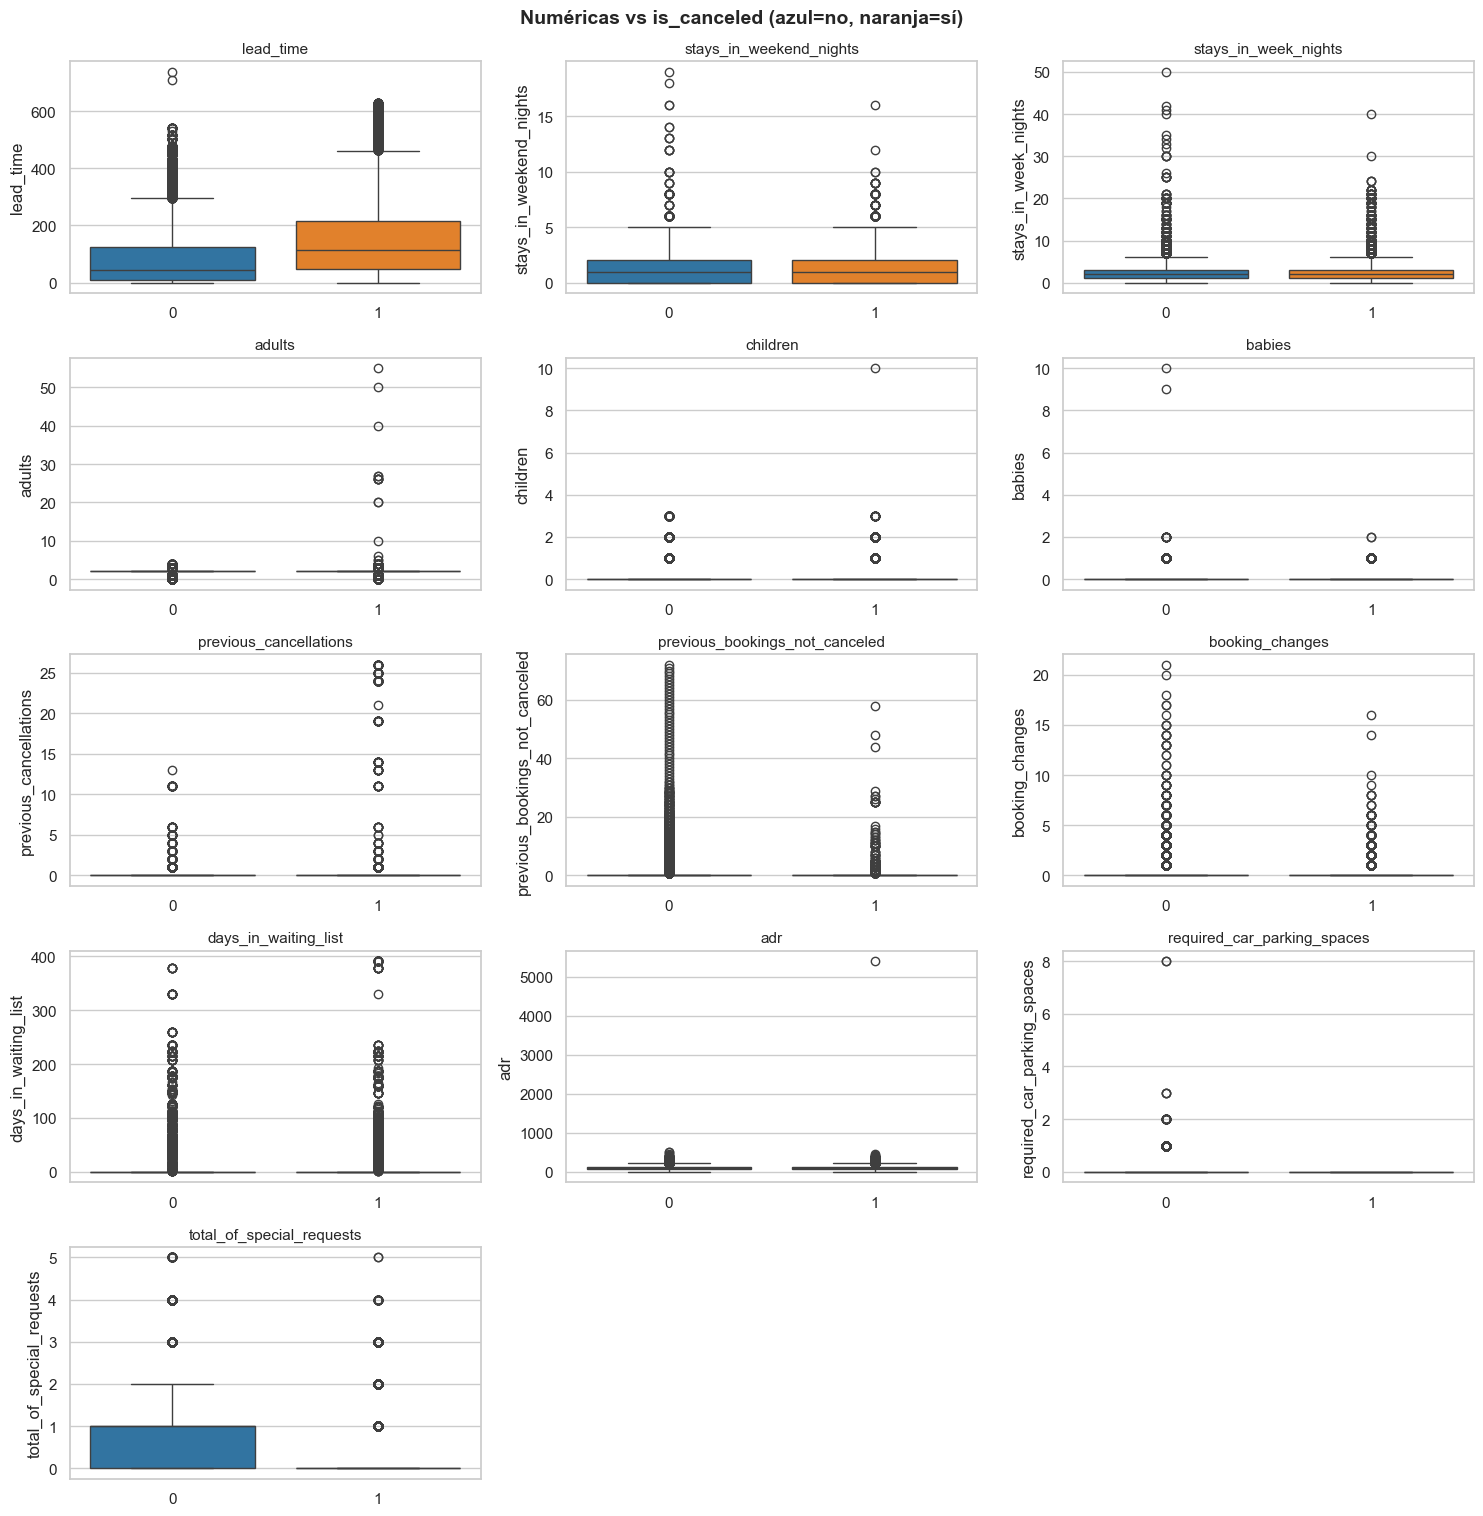

In [25]:
"""Boxplots de las numéricas reales agrupados por is_canceled."""

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUMERICAS_REALES):
    sns.boxplot(
        data=df,
        x=TARGET_COLUMN,
        y=col,
        palette=COLOR_PALETTE,
        ax=axes[i],
    )
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].set_xlabel("")

for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Numéricas vs is_canceled (azul=no, naranja=sí)", y=1.01, fontsize=14, fontweight="bold")
plt.show()

**Observaciones del análisis bivariado:**

**Variables con clara capacidad predictiva** (cajas claramente diferentes entre clases):

- **`lead_time`**: las reservas canceladas tienen lead_time MUCHO mayor que las no canceladas.
  Lógica: las reservas hechas con mucha antelación tienen más tiempo para cambiar de planes.
  **Probablemente la variable más predictiva del dataset.**
- **`total_of_special_requests`**: las cancelaciones tienen MENOS peticiones especiales.
  Lógica: un cliente que pide cuna, late check-in o cama extra está más comprometido con el viaje.
- **`required_car_parking_spaces`**: los que piden parking apenas cancelan.
  Lógica: organizar parking implica "compromiso operativo" con el viaje.
- **`booking_changes`**: las reservas con muchos cambios cancelan menos. Cuanto más
  modifica el cliente la reserva, más implicado está.

**Variables con capacidad predictiva moderada**:

- **`previous_cancellations`**: clientes que cancelaron antes tienden a cancelar de nuevo.
  Patrón claro pero el efecto está concentrado en pocos clientes (la mayoría tiene 0).
- **`adr`**: ligera tendencia a que las reservas caras se cancelen más.

**Variables con poca capacidad predictiva** (cajas muy solapadas):

- `stays_in_week_nights`, `stays_in_weekend_nights`, `adults`, `children`, `babies`.
  La duración y composición de la estancia no parece diferenciar mucho entre los que
  cancelan y los que no.

**Implicación**: los modelos basados en árboles (Random Forest, XGBoost) probablemente
seleccionarán `lead_time`, `total_of_special_requests` y `required_car_parking_spaces`
como las variables numéricas más importantes.

In [26]:
"""Diferencia de medias entre clases para cada numérica real."""

dif_medias = df.groupby(TARGET_COLUMN)[NUMERICAS_REALES].mean().T
dif_medias.columns = ["media_no_cancelado", "media_cancelado"]
dif_medias["diferencia_abs"] = (dif_medias["media_cancelado"] - dif_medias["media_no_cancelado"]).round(2)
dif_medias["dif_relativa_%"] = (
    (dif_medias["diferencia_abs"] / dif_medias["media_no_cancelado"].replace(0, np.nan)) * 100
).round(1)

dif_medias.reindex(dif_medias["dif_relativa_%"].abs().sort_values(ascending=False).index)

,media_no_cancelado,media_cancelado,diferencia_abs,dif_relativa_%
previous_cancellations,0.015792,0.208348,0.19,1203.2
days_in_waiting_list,1.589868,3.564083,1.97,123.9
required_car_parking_spaces,0.099300,0.000000,-0.10,-100.7
babies,0.010377,0.003821,-0.01,-96.4
previous_bookings_not_canceled,0.202977,0.025122,-0.18,-88.7
lead_time,79.984687,144.848815,64.86,81.1
booking_changes,0.293364,0.098340,-0.20,-68.2
total_of_special_requests,0.714060,0.328826,-0.39,-54.6
adr,99.987693,104.964333,4.98,5.0
stays_in_week_nights,2.464053,2.561912,0.10,4.1


**Interpretación de las diferencias de medias:**

La columna `dif_relativa_%` cuantifica numéricamente lo que viste visualmente en los boxplots.

- **Diferencias relativas grandes en valor absoluto** confirman variables predictivas.
- **Diferencias cercanas a 0** son variables que probablemente aportan poco al modelo.
- **Signo de la diferencia**:
  - **Positivo**: la media de cancelados es mayor que la de no cancelados.
    Ejemplo: `lead_time` con diferencia positiva grande → las cancelaciones tienden a
    tener mayor lead_time.
  - **Negativo**: la media de cancelados es menor que la de no cancelados.
    Ejemplo: `total_of_special_requests` negativo → los cancelados piden menos peticiones especiales.

**Esto NO es un test estadístico riguroso** (no hemos calculado p-valores), pero sirve
como exploración rápida. Para confirmar significancia se haría un test t o Mann-Whitney,
pero no es necesario para nuestros objetivos: los modelos descubrirán las relaciones por
sí solos durante el entrenamiento.

### 3.4. Correlaciones entre variables numéricas

Buscamos variables muy correlacionadas entre sí (redundancia). Si dos variables
están altamente correlacionadas (`|r| > 0.7`), una puede ser eliminada sin pérdida
significativa de información. Esto ayuda a:

- Evitar **multicolinealidad** en modelos lineales (la regresión logística sufre).
- Acelerar entrenamiento.
- Mejorar interpretabilidad.

**¿Qué es la correlación de Pearson?**

El coeficiente de correlación de Pearson (`r`) mide la **fuerza y dirección de la
relación lineal** entre dos variables numéricas. Va de -1 a +1:

- `r = +1`: relación lineal positiva perfecta (cuando una sube, la otra sube proporcionalmente).
- `r = +0.7` a `+0.9`: correlación positiva fuerte.
- `r = +0.3` a `+0.7`: correlación positiva moderada.
- `r ≈ 0`: sin relación lineal (las variables son independientes linealmente).
- `r = -0.3` a `-0.7`: correlación negativa moderada (una sube, otra baja).
- `r = -1`: relación lineal negativa perfecta.

**Limitaciones importantes a recordar:**

- Pearson **solo detecta relaciones LINEALES**. Si dos variables tienen una relación
  cuadrática perfecta (y = x²), Pearson puede dar 0.
- Pearson asume **datos numéricos**. No sirve para categóricas.
- **Correlación NO implica causalidad**: que dos variables suban juntas no significa
  que una cause la otra; puede haber una tercera variable común.
- Pearson es **sensible a outliers**. Un outlier puede inflar artificialmente la correlación.

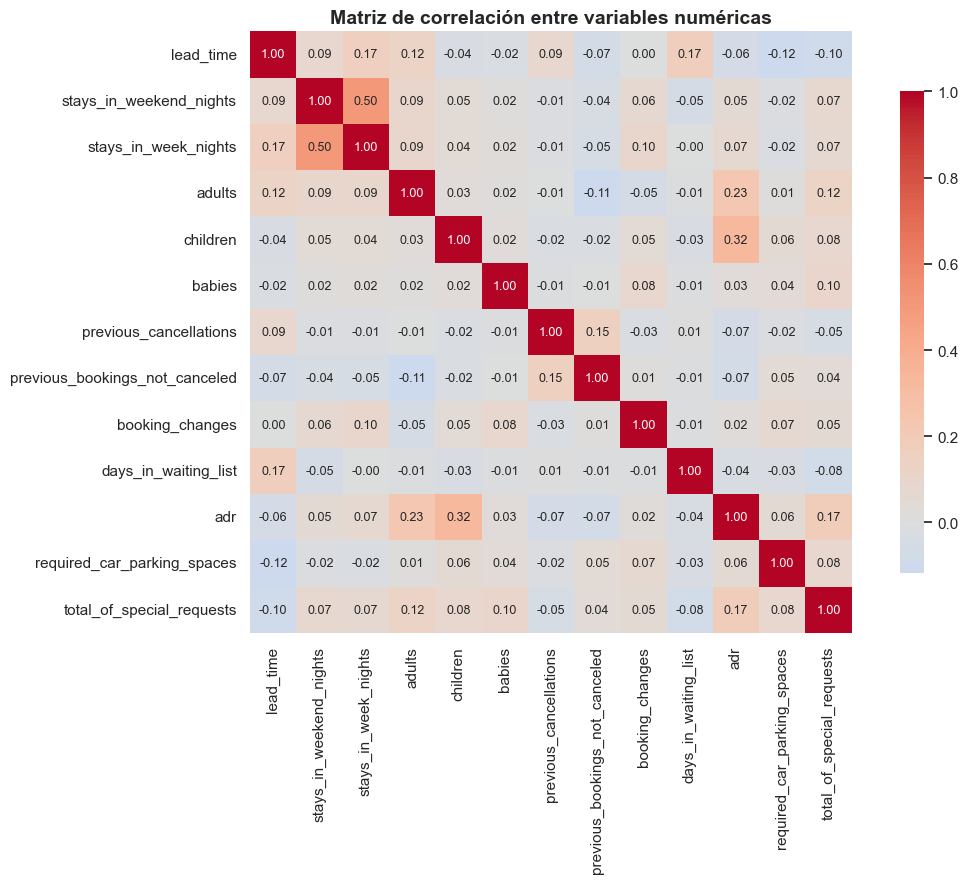

In [27]:
"""Matriz de correlación de Pearson entre numéricas reales."""

corr_matrix = df[NUMERICAS_REALES].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Cómo leer el heatmap:**

- **Colores rojos** (valores cercanos a +1): correlación positiva fuerte.
- **Colores azules** (valores cercanos a -1): correlación negativa fuerte.
- **Colores neutros (blancos / pálidos)**: correlación cercana a 0 (variables independientes linealmente).
- La **diagonal** es siempre 1.0 (autocorrelación, una variable consigo misma).
- La matriz es **simétrica**: corr(A, B) = corr(B, A).

**Observaciones del heatmap concreto:**

**Mayoría de correlaciones cerca de 0**: las variables numéricas son razonablemente
independientes entre sí. Esto es **bueno** porque significa que cada variable aporta
información distinta al modelo.

**Correlación positiva moderada** entre `stays_in_weekend_nights` y `stays_in_week_nights`
(~0.5). Tiene sentido: las estancias largas suelen incluir tanto fines de semana como entre
semana. No es lo suficientemente alta como para considerar eliminar una.

**Correlación positiva moderada** entre `previous_cancellations` y
`previous_bookings_not_canceled` (~0.4). Indica que un cliente "habitual" del hotel ha
tenido reservas previas tanto canceladas como completadas. La correlación no es muy alta
porque hay muchos clientes con 0 en ambas variables (la mayoría son nuevos clientes, no repetidos).

**Variables casi independientes**: `lead_time`, `adr`, `adults`, `babies`, `children`
tienen correlaciones cercanas a 0 entre ellas. Cada una aporta su propia información.

**Sin correlaciones críticas (|r| > 0.7)**: no hay variables tan redundantes como para
justificar eliminar alguna por colinealidad. Las dejamos todas.

**Implicación**:

- **No hay riesgo grave de multicolinealidad**. La regresión logística funcionará bien sin
  preocupaciones de variables redundantes.
- **Los modelos de árboles (Random Forest, XGBoost) son naturalmente robustos** a
  variables correlacionadas: aunque dos variables estuvieran muy correlacionadas, simplemente
  elegirían una u otra en sus splits. La correlación no les afecta tanto como a los modelos lineales.
- **Pearson solo capta lo lineal**. Aunque dos variables aparezcan con r≈0 en el heatmap,
  podrían tener una relación NO lineal que los modelos sí captarán.

In [30]:
"""Identificar pares de variables con correlación > 0.5 en valor absoluto."""

UMBRAL_CORR = 0.5

# Convertir matriz de correlación a tabla de pares
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
# Eliminar autocorrelaciones (r = 1.0) y duplicados (var1-var2 y var2-var1)
corr_pairs = corr_pairs[corr_pairs < 1.0].reset_index()
corr_pairs.columns = ["var1", "var2", "abs_correlacion"]
corr_pairs["par"] = corr_pairs.apply(lambda r: tuple(sorted([r["var1"], r["var2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates("par").drop(columns="par")

altas = corr_pairs[corr_pairs["abs_correlacion"] > UMBRAL_CORR]
print(f"Pares con |correlación| > {UMBRAL_CORR}: {len(altas)}")
altas.head(10)

Pares con |correlación| > 0.5: 0


,var1,var2,abs_correlacion


**Análisis de pares con correlación notable:**

Hemos bajado el umbral a 0.5 (en lugar del 0.7 estándar) para asegurarnos de no perder
ningún par moderadamente correlacionado.

- Si la tabla está vacía o tiene pocos pares con `abs_correlacion < 0.7`, **no eliminamos
  ninguna variable por redundancia**.
- Solo si encontráramos `abs_correlacion > 0.9` consideraríamos eliminar una de las dos
  variables del par. Hasta 0.7-0.8 mantenemos ambas porque pueden aportar información
  complementaria que el modelo aprovechará.

**Decisión final**: ninguna eliminación por correlación. Mantenemos las 13 numéricas reales.

### 3.5. Resumen de la Sección 3 y decisiones de preprocesamiento

**Hallazgos:**

- **13 variables numéricas reales** identificadas (excluyendo IDs, temporales y binarias).
- **Distribuciones muy asimétricas** en `lead_time`, `adr`, `previous_cancellations`,
  `days_in_waiting_list`, `booking_changes`. Candidatas a transformación logarítmica.
- **Outliers extremos confirmados**:
  - `adr`: valores negativos (errores) y máximo 5400 € (outliers reales).
  - `adults`: max 55 (probable error de captura).
- **Variables más predictivas a primera vista**:
  - `lead_time`: las cancelaciones tienen lead_time mucho mayor.
  - `previous_cancellations`: clientes que cancelaron antes tienden a cancelar de nuevo.
  - `total_of_special_requests`: a más peticiones, menos cancelaciones.
  - `required_car_parking_spaces`: prácticamente todos los que piden parking NO cancelan.
- **Correlaciones**: ninguna excesivamente alta. No hay variables redundantes obvias.

**Decisiones de preprocesamiento:**

- **Eliminar outliers imposibles**: `adr` negativos (precios sin sentido) y `adults > 10`
  (errores de captura).
- **Considerar transformación log** para `lead_time` y `adr` (asimetría alta).
- **Aplicar StandardScaler** en modelos sensibles a escala (Regresión Logística, Red Neuronal).
- **NO eliminar variables por correlación** (no hay pares con r > 0.7).
- Variables clave esperadas para los modelos basados en árboles: `lead_time`,
  `previous_cancellations`, `total_of_special_requests`.